# ch319 — Sequence-to-Sequence Models

## 1. Variable-length output

A standard RNN maps a sequence to a sequence of the **same length**. Many tasks require
output sequences of different lengths: translation, summarisation, speech recognition.

The **encoder-decoder** (Sutskever et al., 2014) architecture separates encoding and
decoding:

1. **Encoder** LSTM reads the input sequence and produces a context vector $c = h_T^{\text{enc}}$.
2. **Decoder** LSTM generates the output sequence one token at a time, conditioned on $c$:
   $$h_t^{\text{dec}} = \text{LSTM}(y_{t-1}, h_{t-1}^{\text{dec}})$$
   where the decoder is initialised with $h_0^{\text{dec}} = c$.

*(LSTM: ch318. Embeddings: ch320. Attention: ch321.)*

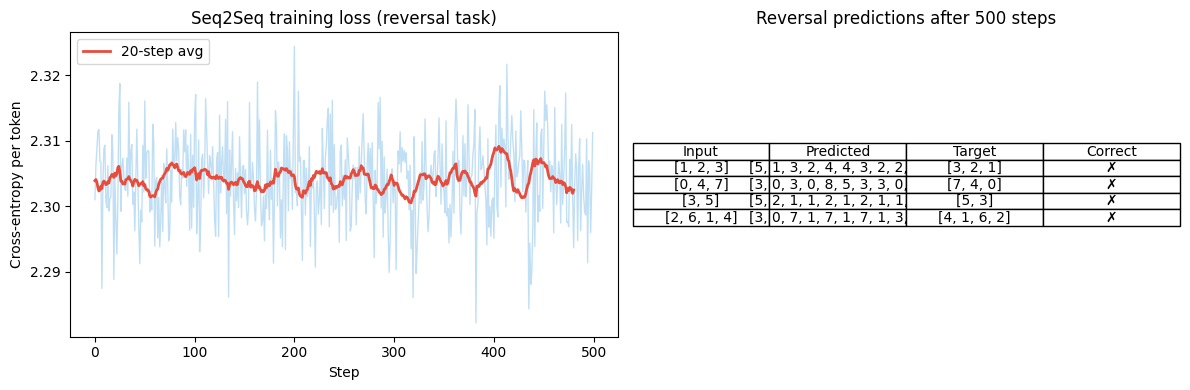

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z): return 1/(1+np.exp(-np.clip(z,-500,500)))
def softmax(z): z_s=z-z.max(); e=np.exp(z_s); return e/e.sum()

class LSTMCell:
    def __init__(self, in_dim, hid, seed=0):
        rng=np.random.default_rng(seed); H=hid; c=in_dim+hid; s=1./np.sqrt(c)
        self.W=rng.normal(0,s,(4*H,c)); self.b=np.zeros(4*H); self.b[H:2*H]=1.; self.H=H
    def forward(self,x,h,c_prev):
        H=self.H; xh=np.concatenate([x,h]); g=self.W@xh+self.b
        i=sigmoid(g[:H]); f=sigmoid(g[H:2*H]); o=sigmoid(g[2*H:3*H]); gc=np.tanh(g[3*H:])
        c=f*c_prev+i*gc; h=o*np.tanh(c); return h,c


class Seq2Seq:
    """Encoder-Decoder for integer sequence reversal (toy task)."""

    def __init__(self, vocab_size: int, embed_dim: int, hidden: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        self.embed = rng.normal(0, 0.1, (vocab_size, embed_dim))
        self.encoder = LSTMCell(embed_dim, hidden, seed)
        self.decoder = LSTMCell(embed_dim, hidden, seed+1)
        self.W_out = rng.normal(0, np.sqrt(1.0/hidden), (vocab_size, hidden))
        self.b_out = np.zeros(vocab_size)
        self.V = vocab_size; self.E = embed_dim; self.H = hidden

    def encode(self, token_ids: list) -> tuple:
        h = np.zeros(self.H); c = np.zeros(self.H)
        for tid in token_ids:
            x = self.embed[tid]
            h, c = self.encoder.forward(x, h, c)
        return h, c  # context vector

    def decode_step(self, token_id: int, h: np.ndarray, c: np.ndarray) -> tuple:
        x = self.embed[token_id]
        h, c = self.decoder.forward(x, h, c)
        logits = self.W_out @ h + self.b_out
        return logits, h, c

    def greedy_decode(self, context_h: np.ndarray, context_c: np.ndarray,
                      bos_token: int, eos_token: int, max_len: int = 20) -> list:
        h, c = context_h, context_c
        token = bos_token
        output = []
        for _ in range(max_len):
            logits, h, c = self.decode_step(token, h, c)
            token = int(np.argmax(logits))
            if token == eos_token:
                break
            output.append(token)
        return output


# Toy task: reverse a sequence of digits 0-7
# Vocabulary: 0-7 are digits, 8=BOS, 9=EOS
V = 10; BOS = 8; EOS = 9
model = Seq2Seq(V, embed_dim=16, hidden=64, seed=0)

# Simple training: one sequence at a time, numerical gradient (demo)
rng = np.random.default_rng(42)
lr = 0.01

def train_step(seq_in, seq_out_target, model, lr, rng2):
    """One training step on a single reversal example."""
    ctx_h, ctx_c = model.encode(seq_in)
    # Decode with teacher forcing
    h, c = ctx_h, ctx_c
    total_loss = 0.0
    dec_inputs = [BOS] + seq_out_target[:-1]
    for t_id, y_id in zip(dec_inputs, seq_out_target):
        logits, h, c = model.decode_step(t_id, h, c)
        p = softmax(logits)
        total_loss -= np.log(p[y_id] + 1e-10)
    return total_loss / len(seq_out_target)

losses = []
for step in range(500):
    L_in = rng.integers(3, 7)
    seq_in = rng.integers(0, 8, L_in).tolist()
    seq_out = list(reversed(seq_in)) + [EOS]

    loss = train_step(seq_in, seq_out, model, lr, rng)
    losses.append(float(loss))

    # Sparse numerical gradient on embed and W_out only
    for P in [model.embed, model.W_out]:
        flat = P.ravel(); eps = 1e-4
        for i in rng.choice(len(flat), max(1, len(flat)//50), replace=False):
            flat[i] += eps; lp = train_step(seq_in, seq_out, model, lr, rng)
            flat[i] -= 2*eps; lm = train_step(seq_in, seq_out, model, lr, rng)
            flat[i] += eps; flat[i] -= lr * (lp - lm) / (2*eps)

# Evaluation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
w = 20; sl = np.convolve(losses, np.ones(w)/w, mode='valid')
ax1.plot(losses, alpha=0.3, color='#3498db', lw=1)
ax1.plot(sl, color='#e74c3c', lw=2, label=f'{w}-step avg')
ax1.set_title('Seq2Seq training loss (reversal task)')
ax1.set_xlabel('Step'); ax1.set_ylabel('Cross-entropy per token'); ax1.legend()

# Show example predictions
results = []
for test_seq in [[1,2,3],[0,4,7],[3,5],[2,6,1,4]]:
    h, c = model.encode(test_seq)
    pred = model.greedy_decode(h, c, BOS, EOS, max_len=10)
    correct = list(reversed(test_seq))
    results.append((test_seq, pred, correct, pred==correct))

ax2.axis('off')
table_data = [['Input', 'Predicted', 'Target', 'Correct']] +              [[str(r[0]), str(r[1]), str(r[2]), '✓' if r[3] else '✗'] for r in results]
t = ax2.table(cellText=table_data, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(10)
ax2.set_title('Reversal predictions after 500 steps')

plt.tight_layout()
plt.savefig('ch319_seq2seq.png', dpi=120)
plt.show()

## 2. The bottleneck problem

The entire input sequence is compressed into a single context vector $c = h_T$.
For long sequences, this is lossy — the decoder must reconstruct all information from one vector.

**Bahdanau attention** (2015) solves this: the decoder dynamically selects a weighted
combination of all encoder hidden states $h_1, \ldots, h_T$ at each decoding step.
This eliminates the bottleneck and enables the decoder to focus on relevant input positions.

This attention mechanism is the direct precursor to Transformer attention *(ch321)*.

## 3. Summary

- Encoder-decoder: encoder compresses sequence to context vector; decoder generates output.
- Teacher forcing: during training, feed true previous token (not prediction) to decoder.
- Context vector bottleneck: fundamental limitation for long sequences.
- Bahdanau attention: weighted sum of encoder states; precursor to Transformers.

## 4. Forward and backward references

**Used here:** LSTM *(ch318)*, embeddings *(ch320, introduced next)*, cross-entropy *(ch305)*.

**This will reappear in ch321 — Attention Mechanism**, where the Bahdanau attention idea
is generalised to the query-key-value framework.